In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import time
import copy
import matplotlib.pyplot as plt

In [2]:
# 1. Hàm hỗ trợ MixUp
# Trộn ngẫu nhiên 2 ảnh và 2 nhãn 
def mixup_data(x, y, alpha=0.2, use_cuda=True):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    if use_cuda:
        index = torch.randperm(batch_size).cuda()
    else:
        index = torch.randperm(batch_size)

    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

# Tính toán Loss dựa theo tỷ lệ trộn
def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

In [3]:
# 2. Chuẩn bị dữ liệu 
data_dir = '/kaggle/input/notebooks/xunctrn/eda-preprocessing/Clean_FER2013'

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # Đưa về chuẩn đầu vào của ResNet50
    transforms.RandomHorizontalFlip(p=0.5), # Lật ngang 50%
    transforms.RandomRotation(15), # Xoay ngẫu nhiên
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # Thêm nhiễu ánh sáng
    transforms.ToTensor(), # Chuyển thành Tensor trước khi xóa ngẫu nhiên
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), value=0) # Che khuất một phần khuôn mặt
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

batch_size = 32
train_loader = DataLoader(datasets.ImageFolder(root=f'{data_dir}/train', transform=train_transforms), batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(datasets.ImageFolder(root=f'{data_dir}/test', transform=test_transforms), batch_size=batch_size, shuffle=False, num_workers=2)

In [4]:
# 3. Khởi tạo mô hình
print("Khởi tạo mạng ResNet50...")
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# Đóng băng toàn bộ mạng
for param in model.parameters():
    param.requires_grad = False

# Chỉ mở khóa layer4 
for param in model.layer4.parameters():
    param.requires_grad = True

# Chèn lớp Dropout 50% 
num_ftrs = model.fc.in_features 
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, 4)
)

for param in model.fc.parameters():
    param.requires_grad = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

Khởi tạo mạng ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


In [5]:
# 4. Thuật toán tối ưu
criterion = nn.CrossEntropyLoss()
# Dùng AdamW thay vì Adam thường để tương thích tốt nhất với Weight Decay và Cosine LR
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, weight_decay=1e-4)

num_epochs = 50
# Cosine Annealing LR - Giảm tốc độ học mượt mà theo hình Sin
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [6]:
# 5. Vòng lặp huấn luyện 
# Các mảng lưu lại lịch sử vẽ biểu đồ
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

# Biến để lưu lại mô hình tốt nhất
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

# Cài đặt thông số Early Stopping
patience = 8
epochs_no_improve = 0
early_stop = False

print("\n🚀 BẮT ĐẦU HUẤN LUYỆN...\n")
start_time = time.time()

for epoch in range(num_epochs):
    if early_stop:
        print("🛑 Đã kích hoạt Early Stopping.")
        break
        
    print(f"Epoch {epoch+1}/{num_epochs}")
    print("-" * 20)

    if epoch == 10:
        print("🔓 Mở khóa Layer 3...")
        for param in model.layer3.parameters():
            param.requires_grad = True
        
        # Nạp lại Optimizer với các tham số mới
        optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
        # Reset lại lịch trình Cosine cho quãng đường còn lại
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=(num_epochs - 10))
        print("⚙️ Đã cập nhật Optimizer và ép tốc độ học xuống mức tinh chỉnh (Fine-tuning)!")

    for phase in ['train', 'test']:
        if phase == 'train':
            model.train() # Bật chế độ huấn luyện (cho phép cập nhật trọng số, kích hoạt Dropout/BatchNorm)
            dataloader = train_loader
        else:
            model.eval() # Bật chế độ đánh giá (đóng băng trọng số)
            dataloader = test_loader

        running_loss = 0.0
        running_corrects = 0.0

        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                # Kích hoạt MixUp trong pha Train
                if phase == 'train':
                    inputs, targets_a, targets_b, lam = mixup_data(inputs, labels, alpha=0.2)
                    outputs = model(inputs)
                    loss = mixup_criterion(criterion, outputs, targets_a, targets_b, lam)
                    
                    _, preds = torch.max(outputs, 1)
                    loss.backward()
                    optimizer.step()
                    
                    # Tính Accuracy xấp xỉ cho dữ liệu trộn
                    corrects = (lam * preds.eq(targets_a.data).cpu().sum().float() + 
                                (1 - lam) * preds.eq(targets_b.data).cpu().sum().float())
                    running_corrects += corrects
                else:
                    # TEST-TIME AUGMENTATION (TTA 2x)
                    # Đoán trên ảnh gốc
                    outputs_orig = model(inputs)
                    
                    # Đoán trên ảnh lật ngang (Horizontal Flip)
                    inputs_flipped = torch.flip(inputs, dims=[3]) 
                    outputs_flipped = model(inputs_flipped)
                    
                    # Lấy trung bình cộng xác suất của 2 lần đoán
                    outputs_tta = (outputs_orig + outputs_flipped) / 2.0
                    
                    _, preds = torch.max(outputs_tta, 1)
                    loss = criterion(outputs_tta, labels) # Tính loss dựa trên kết quả đã TTA
                    
                    running_corrects += torch.sum(preds == labels.data).float()

            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(dataloader.dataset)
        epoch_acc = running_corrects / len(dataloader.dataset)

        history[f'{phase}_loss'].append(epoch_loss)
        history[f'{phase}_acc'].append(epoch_acc.item())

        print(f"{phase.capitalize()} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

        # Checkpoint & Early Stopping dựa trên Test Accuracy
        if phase == 'test':
            if epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                print(f"🌟 Đã cập nhật mô hình tốt nhất! (Accuracy: {best_acc:.4f})")
            else:
                epochs_no_improve += 1
                print(f"⏳ Early Stopping đếm ngược: {epochs_no_improve}/{patience}")
                if epochs_no_improve >= patience:
                    early_stop = True

    # Cập nhật bộ giảm tốc độ học Cosine sau mỗi epoch
    scheduler.step()
    print()

time_elapsed = time.time() - start_time
print(f"✅ Hoàn tất trong {time_elapsed // 60:.0f} phút {time_elapsed % 60:.0f} giây")
print(f"🏆 Độ chính xác cao nhất trên tập Test (Best Test Acc): {best_acc:.4f}")

# Nạp lại và lưu mô hình xuất sắc nhất
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), '/kaggle/working/best_emotion_model.pt')
print("\n💾 Đã lưu file: /kaggle/working/best_emotion_model.pt")


🚀 BẮT ĐẦU HUẤN LUYỆN...

Epoch 1/50
--------------------
Train | Loss: 1.0336 | Accuracy: 0.5684
Test | Loss: 0.7093 | Accuracy: 0.7306
🌟 Đã cập nhật mô hình tốt nhất! (Accuracy: 0.7306)

Epoch 2/50
--------------------
Train | Loss: 0.8863 | Accuracy: 0.6500
Test | Loss: 0.5941 | Accuracy: 0.7840
🌟 Đã cập nhật mô hình tốt nhất! (Accuracy: 0.7840)

Epoch 3/50
--------------------
Train | Loss: 0.8407 | Accuracy: 0.6655
Test | Loss: 0.6542 | Accuracy: 0.7475
⏳ Early Stopping đếm ngược: 1/8

Epoch 4/50
--------------------
Train | Loss: 0.8038 | Accuracy: 0.6860
Test | Loss: 0.6392 | Accuracy: 0.7533
⏳ Early Stopping đếm ngược: 2/8

Epoch 5/50
--------------------
Train | Loss: 0.7911 | Accuracy: 0.6941
Test | Loss: 0.6325 | Accuracy: 0.7900
🌟 Đã cập nhật mô hình tốt nhất! (Accuracy: 0.7900)

Epoch 6/50
--------------------
Train | Loss: 0.7928 | Accuracy: 0.6908
Test | Loss: 0.5604 | Accuracy: 0.7975
🌟 Đã cập nhật mô hình tốt nhất! (Accuracy: 0.7975)

Epoch 7/50
--------------------
Tr

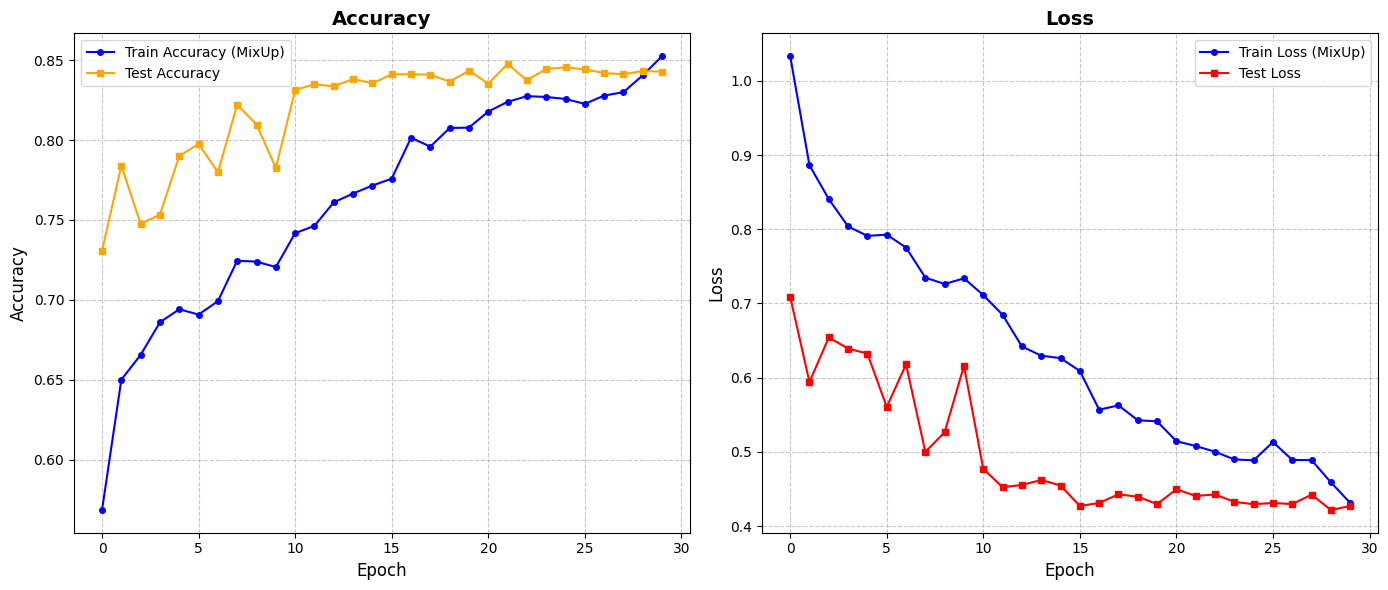

In [7]:
# 6. Vẽ biểu đồ báo cáo
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy (MixUp)', color='blue', marker='o', markersize=4)
plt.plot(history['test_acc'], label='Test Accuracy', color='orange', marker='s', markersize=4)
plt.title('Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss (MixUp)', color='blue', marker='o', markersize=4)
plt.plot(history['test_loss'], label='Test Loss', color='red', marker='s', markersize=4)
plt.title('Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('/kaggle/working/emotion_chart.png', dpi=300)
plt.show()

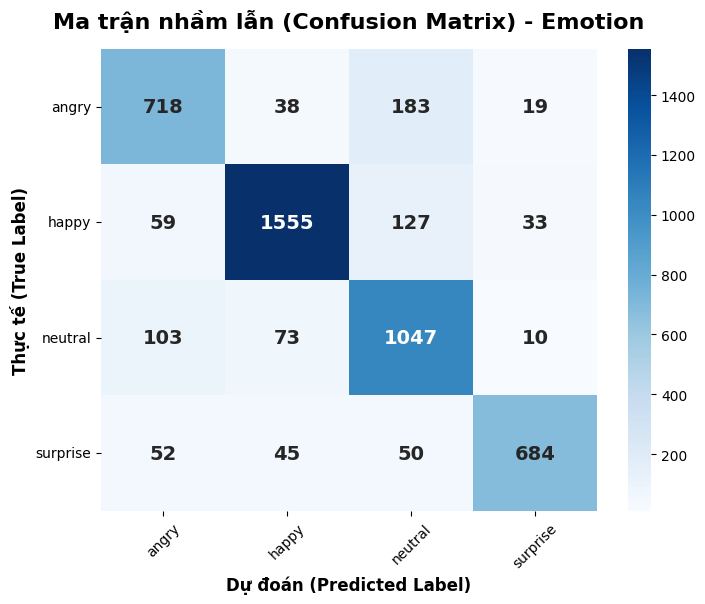

📸 Đã lưu thành công biểu đồ tại: /kaggle/working/emotion_confusion_matrix.png


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.load_state_dict(torch.load('/kaggle/working/best_emotion_model.pt'))
model.eval() 

y_true = []
y_pred = []

# Chạy mô hình qua tập Test để thu thập dự đoán
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        # Lưu lại nhãn thực tế và nhãn dự đoán
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Lấy tên 4 cảm xúc từ dataset
class_names = test_loader.dataset.classes

# Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# Vẽ biểu đồ 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14, "weight": "bold"}) 

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - Emotion', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Dự đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('Thực tế (True Label)', fontsize=12, fontweight='bold')

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.savefig('/kaggle/working/emotion_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("📸 Đã lưu thành công biểu đồ tại: /kaggle/working/emotion_confusion_matrix.png")